# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

plt.style.use('fivethirtyeight')

In [2]:
df = pd.read_csv("Employee_productivity.csv")

In [3]:
df.shape

(300, 7)

In [4]:
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [5]:
df.dtypes

HoursWorked            float64
FocusScore             float64
ProductivityScore      float64
Department              object
YearsAtCompany           int64
TeamMeetingsPerWeek      int64
DeskLocation            object
dtype: object

# 1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity. Show a visualization and calculate R-squared for all three relationships to justify your answer. 

In [6]:
y = df["ProductivityScore"]

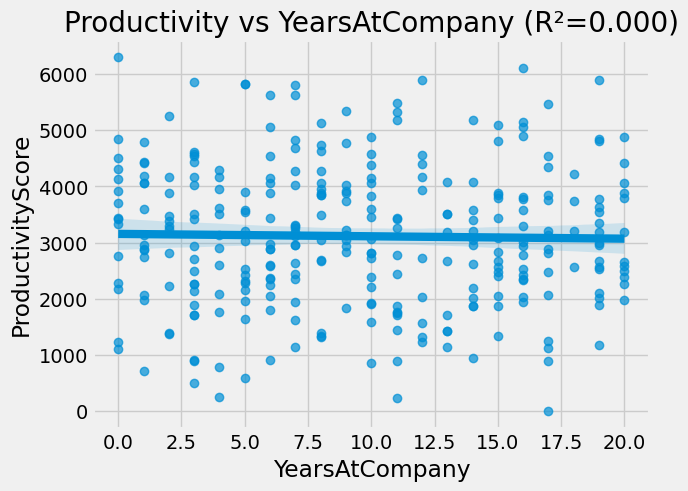

In [7]:
X_years = sm.add_constant(df["YearsAtCompany"])
m_years = sm.OLS(y, X_years).fit()
sns.regplot(x=df["YearsAtCompany"], y=y, scatter_kws={"alpha":0.7})
plt.title(f"Productivity vs YearsAtCompany (R²={m_years.rsquared:.3f})")
plt.xlabel("YearsAtCompany"); plt.ylabel("ProductivityScore")
plt.show()

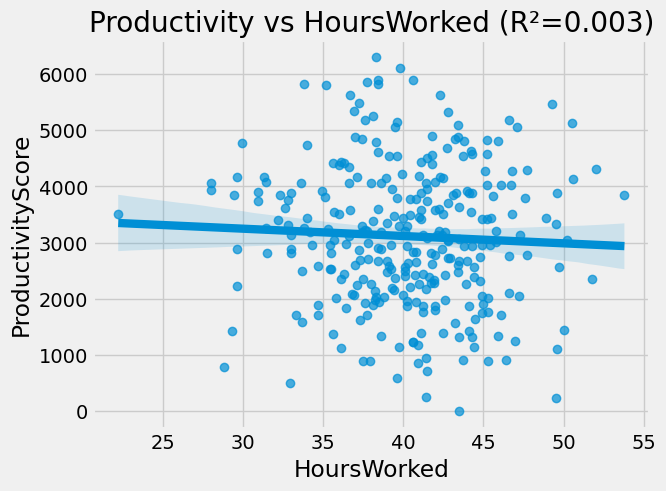

In [8]:
X_hours = sm.add_constant(df["HoursWorked"])
m_hours = sm.OLS(y, X_hours).fit()
sns.regplot(x=df["HoursWorked"], y=y, scatter_kws={"alpha":0.7})
plt.title(f"Productivity vs HoursWorked (R²={m_hours.rsquared:.3f})")
plt.xlabel("HoursWorked"); plt.ylabel("ProductivityScore")
plt.show()

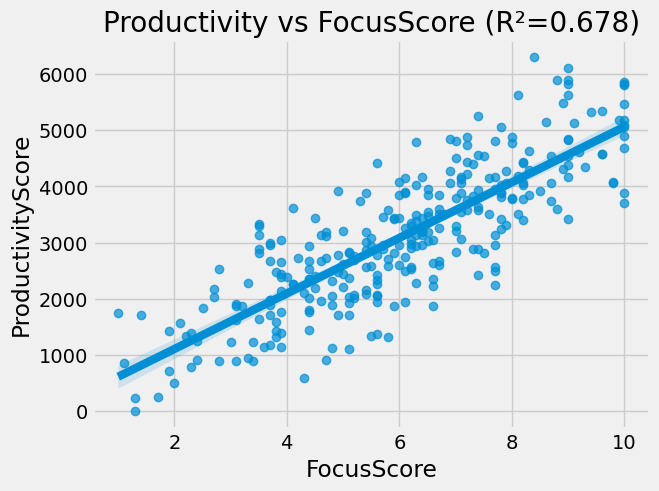

In [9]:
X_focus = sm.add_constant(df["FocusScore"])
m_focus = sm.OLS(y, X_focus).fit()
sns.regplot(x=df["FocusScore"], y=y, scatter_kws={"alpha":0.7})
plt.title(f"Productivity vs FocusScore (R²={m_focus.rsquared:.3f})")
plt.xlabel("FocusScore"); plt.ylabel("ProductivityScore")
plt.show()

# 2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

In [12]:
num_feats = ["FocusScore", "HoursWorked", "YearsAtCompany", "TeamMeetingsPerWeek"]
X_num = df[num_feats].copy()

cats = ["Department", "DeskLocation"]
X_cats = pd.get_dummies(df[cats], drop_first=True)

X = pd.concat([X_num, X_cats], axis=1).astype(float)

y = df["ProductivityScore"].astype(float)

In [13]:
Xc = sm.add_constant(X)
full_model = sm.OLS(y, Xc).fit()

full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     70.11
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           1.53e-67
Time:                        22:49:34   Log-Likelihood:                -2390.8
No. Observations:                 300   AIC:                             4802.
Df Residuals:                     290   BIC:                             4839.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                         255.7046    399.258      0.640      0.522    -530.105    1041.515
FocusScore                    512.7193     21.748     23.575      0.000     469.915     555.523
HoursWorked                    -4.6642      8.541     -0.546      0.585     -21.474      12.146
YearsAtCompany                  3.4008      6.992      0.486      0.627     -10.360      17.162
TeamMeetingsPerWeek            27.1706     24.914      1.091      0.276     -21.864      76.206
Department_HR                 -93.3984    115.183     -0.811      0.418    -320.100     133.303
Department_Marketing         -136.2405    118.380     -1.151      0.251    -369.234      96.753
Department_Sales              -49.8174    117.871     -0.423      0.673    -281.809     182.174
DeskLocation_Private Office  -103.4120    100.491     -1.029      0.304    -301.197      94.373
DeskLocation_Remote          -229.7530    106.847     -2.150      0.032    -440.047     -19.459
==============================================================================
Omnibus:                        0.168   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.920   Jarque-Bera (JB):                0.295
Skew:                           0.024   Prob(JB):                        0.863
Kurtosis:                       2.854   Cond. No.                         412.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
X_base = sm.add_constant(df[["FocusScore"]].astype(float))
m_base = sm.OLS(y, X_base).fit()

print("Baseline (Focus only) R²:", round(m_base.rsquared, 3))

Baseline (Focus only) R²: 0.678


In [15]:
X_step1 = sm.add_constant(
    df[["FocusScore", "HoursWorked", "YearsAtCompany", "TeamMeetingsPerWeek"]]
    .astype(float)
)
m_step1 = sm.OLS(y, X_step1).fit()

print("After adding Hours/Years/Meetings R²:", round(m_step1.rsquared, 3))
print("Full model R²:", round(full_model.rsquared, 3))

After adding Hours/Years/Meetings R²: 0.679
Full model R²: 0.685


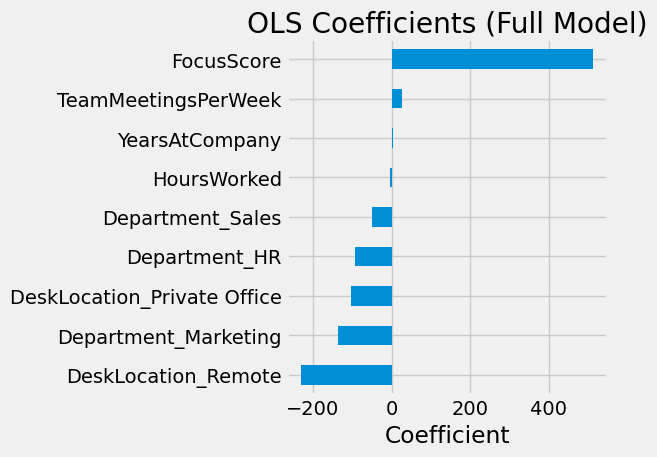

In [16]:
coefs = full_model.params.drop("const")

plt.figure()
coefs.sort_values().plot(kind="barh")
plt.title("OLS Coefficients (Full Model)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

# 3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity. What recommendations would you make so that employees can be as productive as possible?

From the results, focus clearly had the biggest impact on productivity, way more than hours worked or years at the company. Even after adding other factors like meetings, department, and desk location, the model barely improved, which shows focus is the main driver here. Remote and open plan setups seemed to hurt productivity a bit, so helping employees stay focused and cutting down on distractions or unnecessary meetings would probably make the biggest difference.